 Part 1: Setup and Data Loading
### Task 1.1: Import Required Libraries
Import the necessary Python libraries for this lab.
**Required Libraries:**
- pandas
- numpy
- matplotlib.pyplot
- seaborn (optional)

In [20]:
# Import pandas for data manipulation and analysis
import pandas as pd
# Import numpy for numerical operations
import numpy as np
# Import matplotlib for data visualization
import matplotlib.pyplot as plt
# Import seaborn for advanced statistical visualizations
import seaborn as sns


### Task 1.2: Load the Dataset
Load the messy customer data from 'messy_customer_data.csv' into a DataFrame named `df`.

**Hint:** Use `pd.read_csv()`


In [26]:
df = pd.read_csv('/content/customersalesdatacsv-d5esv6krtl0umupil4u0 (2).csv')
df.head()

,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
0,1,John Doe,john.doe@email.com,123-456-7890,2023-01-15,USA,28.0,250.75,Electronics,Credit Card
1,2,jane smith,JANE.SMITH@email.com,(123)4567890,15/02/2023,usa,34.0,340.00,electronics,credit card
2,3,Alice Brown,alice@email.com,1234567890,2023.03.01,United States,45.0,120.50,Clothing,PayPal
3,4,Bob Lee,bob.lee@email,NaN,2022-12-30,Canada,-5.0,0.00,Home,Debit
4,5,Maria Garcia,maria.garcia@email.com,+34 600 123 456,2023/04/10,Spain,39.0,-50.00,Beauty,Cash


### Task 1.3: Display Basic Information

Display the following information about the dataset:
- Shape (rows and columns)
- First 10 rows
- Data types of all columns
- Basic statistical summary


In [27]:
print("Dataset Shape:")
print(df.shape)

print("\nFirst 10 rows:")
print(df.head(10))

print("\nData types:")
print(df.dtypes)

print("\nStatistical Summary:")
print(df.describe(include='all'))


Dataset Shape:
(20, 10)

First 10 rows:
   customer_id      customer_name                   email             phone  \
0            1           John Doe      john.doe@email.com      123-456-7890   
1            2         jane smith    JANE.SMITH@email.com      (123)4567890   
2            3        Alice Brown         alice@email.com        1234567890   
3            4            Bob Lee           bob.lee@email               NaN   
4            5       Maria Garcia  maria.garcia@email.com   +34 600 123 456   
5            6             Li Wei                     NaN   +86 13800138000   
6            7          Omar Khan     omar.khan@email.com   +92-300-1234567   
7            8         Anne-Marie     annemarie@email.com  0044 7700 900123   
8            9       Chris O'Neil   chris.oneil@email.com      123.456.7890   
9           10     Sarah Connor    sarah.connor@email.com       1234567890    

  registration_date        country   age  purchase_amount product_category  \
0        202

## Part 2: Data Exploration and Quality Assessment

### Task 2.1: Identify Missing Values
Write code to:
1. Count missing values in each column
2. Calculate the percentage of missing values per column
3. Display the results

In [33]:
# Count missing values in each column
missing_count = df.isnull().sum()
# Calculate percentage of missing values per column
missing_percentage = (missing_count / len(df)) * 100

# Combine results into a single DataFrame
missing_summary = pd.DataFrame({
    'Missing Values Count': missing_count,
    'Missing Values Percentage (%)': missing_percentage
})
# Display the results
print("Missing Values Summary:")
display(missing_summary)
# Counts all missing values across all rows and columns
missing_count = df.isnull().sum().sum()
print(f"\nTotal number of missing values in the dataset: {missing_count}")
# Question: Which column has the most missing values?
# Answer: Among all columns, the 'phone' column has the highest number of missing values in the dataset.
# Question: What percentage of the dataset is complete?
# Answer: Approximately 93.5% of the dataset is complete, indicating that the majority of the data contains valid, non-missing entries.


Missing Values Summary:


,Missing Values Count,Missing Values Percentage (%)
customer_id,0,0.0
customer_name,1,5.0
email,1,5.0
phone,4,20.0
registration_date,1,5.0
country,0,0.0
age,2,10.0
purchase_amount,1,5.0
product_category,1,5.0
payment_method,2,10.0



Total number of missing values in the dataset: 13


 Task 2.2: Detect Duplicate Records

Write code to:
1. Count the number of duplicate rows
2. Display all duplicate records (if any)
3. Identify which columns contain the duplicated information


In [30]:
# Count the number of duplicate rows
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
#Display all duplicate records (if any)
duplicate_rows = df[df.duplicated(keep=False)]
print("\nDuplicate Records:")
print(duplicate_rows)
# Identify which columns contain duplicated information
duplicate_columns = df.columns[df.nunique() < len(df)]
print("\nColumns that may contain duplicated information:")
print(list(duplicate_columns))

Number of duplicate rows: 0

Duplicate Records:
Empty DataFrame
Columns: [customer_id, customer_name, email, phone, registration_date, country, age, purchase_amount, product_category, payment_method]
Index: []

Columns that may contain duplicated information:
['customer_name', 'email', 'phone', 'registration_date', 'country', 'age', 'purchase_amount', 'product_category', 'payment_method']


Q1. How many duplicate records exist?

A.There are 0 duplicate records in the dataset.

Q2. What makes these records duplicates?

A.Duplicate records are rows where all column values are exactly the same across multiple rows.
In this dataset, no two rows share identical values across all columns, so no duplicates were found.

### Task 2.3: Analyze Data Inconsistencies

Examine the following columns for inconsistencies:
- `customer_name`: Check for formatting issues
- `country`: Check for case variations
- `product_category`: Check for case variations
- `payment_method`: Check for case variations
- `phone`: Check for different formats
- `email`: Check for formatting issues

In [39]:
def print_unique_values(title, series):
    print(title)
    print("-" * 60)
    for i, value in enumerate(series.dropna().unique(), start=1):
        print(f"{i}. {value}")
    print("\n")
# Customer name formatting issues
print_unique_values(
    "Unique Customer Name Formats:",
    df['customer_name']
)
# Country case variations
print_unique_values(
    "Country Variations:",
    df['country']
)
# Product category case variations
print_unique_values(
    "Product Category Variations:",
    df['product_category']
)
# Payment method case variations
print_unique_values(
    "Payment Method Variations:",
    df['payment_method']
)
# Phone number format variations
print_unique_values(
    "Phone Number Formats:",
    df['phone']
)
# Email formatting issues
print_unique_values(
    "Email Formats:",
    df['email']
)


Unique Customer Name Formats:
------------------------------------------------------------
1. John Doe
2. jane smith
3. Alice Brown
4. Bob Lee
5. Maria Garcia
6. Li Wei
7. Omar Khan
8. Anne-Marie
9. Chris O'Neil
10.    Sarah Connor  
11. David Miller
12. Priya Patel
13. Ahmed Ali
14. Sofia Rossi
15. Lucas Martin
16. Emily Clark
17. Daniel Kim
18. Fatima Noor
19. Carlos Diaz


Country Variations:
------------------------------------------------------------
1. USA
2. usa
3. United States
4. Canada
5. Spain
6. China
7. Pakistan
8. UK
9. U.S.A
10. India
11. UAE
12. Italy
13. France
14. South Korea
15. Mexico


Product Category Variations:
------------------------------------------------------------
1. Electronics
2. electronics
3. Clothing
4. Home
5. Beauty
6. Sports
7. clothing


Payment Method Variations:
------------------------------------------------------------
1. Credit Card
2. credit card
3. PayPal
4. Debit
5. Cash
6. Bank Transfer
7. Paypal
8. CREDIT CARD
9. Debit Card
10. UPI


P

### Task 2.4: Identify Invalid Values
Check for invalid values in:
1. `age`: Negative values or unrealistic ages (>120)
2. `purchase_amount`: Negative values or extreme outliers
3. `email`: Invalid email formats

In [47]:
# 1. Check Invalid Age Values
print("Invalid Age Values:")
print("-" * 50)
invalid_age = df[(df['age'] < 0) | (df['age'] > 120)]
if invalid_age.empty:
    print("No invalid age values found.")
else:
    print(invalid_age[['customer_id', 'age']])

print("\n")
# 2. Check Invalid Purchase Amounts
print("Invalid Purchase Amounts:")
print("-" * 50)

invalid_purchase = df[df['purchase_amount'] < 0]

if invalid_purchase.empty:
    print("No invalid purchase amounts found.")
else:
    print(invalid_purchase[['customer_id', 'purchase_amount']])

print("\n")
# 3. Check Invalid Email Formats
print("Invalid Email Formats:")
print("-" * 50)
invalid_email = df[
    df['email'].notna() &
    (
        ~df['email'].str.contains('@', regex=False) |
        ~df['email'].str.contains('.', regex=False)
    )
]

if invalid_email.empty:
    print("No invalid email formats found.")
else:
    print(invalid_email[['customer_id', 'email']])


Invalid Age Values:
--------------------------------------------------
   customer_id  age
3            4 -5.0


Invalid Purchase Amounts:
--------------------------------------------------
    customer_id  purchase_amount
4             5            -50.0
18           19            -20.0


Invalid Email Formats:
--------------------------------------------------
    customer_id          email
5             6               
19           20  invalid_email


## Part 3: Handling Missing Values
### Task 3.1: Create a Cleaning Strategy
Before handling missing values, create a strategy for each column. Fill in the table:
| Column | Strategy | Justification |
|--------|----------|---------------|
| customer_id | | |
| customer_name | | |
| email | | |
| phone | | |
| registration_date | | |
| age | | |
| purchase_amount | | |
| product_category | | |
| payment_method | | |
**Common Strategies:**
- Drop rows with missing values
- Fill with mean/median/mode
- Fill with a constant value
- Forward fill / Backward fill
- Fill with interpolation


In [48]:
import pandas as pd
# Check missing values BEFORE cleaning
print("Missing values before cleaning:")
print(df.isnull().sum())
print("-" * 50)
#Drop rows with missing customer_id or registration_date
df = df.dropna(subset=['customer_id', 'registration_date'])
#Drop rows with missing customer_name
df = df.dropna(subset=['customer_name'])
# Fill missing email with placeholder
df['email'] = df['email'].fillna("unknown@email.com")
# Fill missing phone numbers
df['phone'] = df['phone'].fillna("Not Available")
#  Fill missing age with median
age_median = df['age'].median()
df['age'] = df['age'].fillna(age_median)
# Fill missing purchase amount with median
purchase_median = df['purchase_amount'].median()
df['purchase_amount'] = df['purchase_amount'].fillna(purchase_median)
# Fill missing product category with mode
product_mode = df['product_category'].mode()[0]
df['product_category'] = df['product_category'].fillna(product_mode)
# Fill missing payment method with mode
payment_mode = df['payment_method'].mode()[0]
df['payment_method'] = df['payment_method'].fillna(payment_mode)
# Check missing values AFTER cleaning
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values before cleaning:
customer_id          0
customer_name        1
email                0
phone                4
registration_date    1
country              0
age                  2
purchase_amount      1
product_category     1
payment_method       2
dtype: int64
--------------------------------------------------
Missing values after cleaning:
customer_id          0
customer_name        0
email                0
phone                0
registration_date    0
country              0
age                  0
purchase_amount      0
product_category     0
payment_method       0
dtype: int64


Task 3.2: Implement Missing Value Handling

Create a copy of the original DataFrame called `df_clean` and implement your strategy:
```python
# Create a copy
df_clean = df.copy()


In [99]:
import pandas as pd

# Create a copy of the original DataFrame
# This keeps the original dataset unchanged
df_clean = df.copy()

# Display missing values before handling
print("Missing values before handling:")
print(df_clean.isnull().sum())
print("-" * 50)

# Fill missing customer names with a default value
df_clean['customer_name'] = df_clean['customer_name'].fillna("Unknown")

# Replace missing phone numbers with a readable placeholder
df_clean['phone'] = df_clean['phone'].fillna("Not Available")

# Fill missing registration dates using the most frequent date (mode)
df_clean['registration_date'] = df_clean['registration_date'].fillna(
    df_clean['registration_date'].mode()[0]
)

# Replace missing ages with the median age
# Median is used because it is less affected by extreme values
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Fill missing purchase amounts using the median value
df_clean['purchase_amount'] = df_clean['purchase_amount'].fillna(
    df_clean['purchase_amount'].median()
)

# Fill missing product categories with the most common category
df_clean['product_category'] = df_clean['product_category'].fillna(
    df_clean['product_category'].mode()[0]
)

# Fill missing payment methods with the most frequently used method
df_clean['payment_method'] = df_clean['payment_method'].fillna(
    df_clean['payment_method'].mode()[0]
)

# Display missing values after handling
print("Missing values after handling:")
print(df_clean.isnull().sum())

# Display final dataset shape
print("\nFinal shape of df_clean:", df_clean.shape)


Missing values before handling:
customer_id          0
customer_name        0
email                0
phone                0
registration_date    0
country              0
age                  0
purchase_amount      0
product_category     0
payment_method       0
dtype: int64
--------------------------------------------------
Missing values after handling:
customer_id          0
customer_name        0
email                0
phone                0
registration_date    0
country              0
age                  0
purchase_amount      0
product_category     0
payment_method       0
dtype: int64

Final shape of df_clean: (18, 10)


Task 3.3: Verify Missing Value Handling

Write code to verify that all missing values have been handled appropriately:
**Expected Result:** Zero missing values in all columns (or only in columns you intentionally left with missing values).

In [53]:
# Verify missing values after cleaning
# Count missing values in each column
missing_after_cleaning = df_clean.isnull().sum()
# Display the result
print("Missing values after cleaning:")
print(missing_after_cleaning)
# Check if dataset is fully cleaned
# Total number of missing values in the dataset
total_missing = missing_after_cleaning.sum()
if total_missing == 0:
    print("\n Verification Successful: No missing values remain in the dataset.")
else:
    print(f"\n Verification Warning: {total_missing} missing values still exist.")


Missing values after cleaning:
customer_id          0
customer_name        0
email                0
phone                0
registration_date    0
country              0
age                  0
purchase_amount      0
product_category     0
payment_method       0
dtype: int64

 Verification Successful: No missing values remain in the dataset.


Part 4: Removing Duplicates

### Task 4.1: Remove Duplicate Records

Remove duplicate records from `df_clean`, keeping the first occurrence.

**Hint:** Consider which columns should be used to identify duplicates.


In [54]:
# Check number of rows BEFORE removing duplicates
print("Number of rows before removing duplicates:", df_clean.shape[0])
# Remove duplicate records
# Duplicates are identified using all columns
# keep='first' keeps the first occurrence
df_clean = df_clean.drop_duplicates(keep='first')
# Checking number of rows after removing duplicates
print("Number of rows after removing duplicates:", df_clean.shape[0])
# Verify duplicate removal
duplicate_count = df_clean.duplicated().sum()
print("Number of duplicate rows remaining:", duplicate_count)

Number of rows before removing duplicates: 18
Number of rows after removing duplicates: 18
Number of duplicate rows remaining: 0


### Task 4.2: Verify Duplicate Removal

Verify that no duplicates remain:


In [56]:
# Check for duplicate rows in the cleaned dataset
remaining_duplicates = df_clean.duplicated().sum()
print("Number of duplicate rows remaining:", remaining_duplicates)
# Final confirmation message
if remaining_duplicates == 0:
    print("No duplicate records remain in the dataset.")
else:
    print("Duplicate records are still present.")

Number of duplicate rows remaining: 0
No duplicate records remain in the dataset.


# q1.How many rows were removed?
#  A. 0 rows were removed, as no duplicate records were found in the dataset.
#  q2 .What is the new shape of the dataset?
# A.The dataset shape remains (18, 10) — 18 rows and 10 columns.

Part 5: Data Standardization

### Task 5.1: Standardize Customer Names

Standardize the `customer_name` column to Title Case with no extra whitespace.

**Example:** "  john doe  " → "John Doe"

In [57]:
# Standardize customer_name column
# 1. Remove leading and trailing spaces using strip()
# 2. Convert names to Title Case using title()

df_clean['customer_name'] = (
    df_clean['customer_name']
    .astype(str)        # Ensure all values are strings
    .str.strip()        # Remove extra spaces
    .str.title()        # Convert to Title Case
)

# Verify the changes
print("Standardized Customer Names:")
print(df_clean['customer_name'].unique())


Standardized Customer Names:
['John Doe' 'Jane Smith' 'Alice Brown' 'Bob Lee' 'Maria Garcia' 'Li Wei'
 'Omar Khan' 'Anne-Marie' "Chris O'Neil" 'David Miller' 'Priya Patel'
 'Ahmed Ali' 'Sofia Rossi' 'Lucas Martin' 'Emily Clark' 'Daniel Kim'
 'Fatima Noor' 'Carlos Diaz']


Task 5.2: Standardize Email Addresses
Standardize the email column to lowercase with no extra whitespace.

In [58]:
# Standardize email addresses
df_clean['email'] = (
    df_clean['email']
    .astype(str)
    .str.strip()
    .str.lower()
)

# Check result
print(df_clean['email'].unique())


['john.doe@email.com' 'jane.smith@email.com' 'alice@email.com'
 'bob.lee@email' 'maria.garcia@email.com' '' 'omar.khan@email.com'
 'annemarie@email.com' 'chris.oneil@email.com' 'david.miller@email.com'
 'priya.patel@email.com' 'ahmed.ali@email.com' 'sofia.rossi@email.com'
 'lucas.martin@email.com' 'emily.clark@email.com' 'daniel.kim@email.com'
 'fatima.noor@email.com' 'carlos.diaz@email.com']


Task 5.3: Standardize Phone Numbers
Standardize the phone column to a consistent format: XXX-XXXX

Example: "(555) 1234", "555.1234", "5551234" → "555-1234"

Hint: Remove all non-numeric characters first, then format.



In [60]:
df_clean['phone'] = (
    df_clean['phone']
    .astype(str)
    .str.replace(r'\D', '', regex=True)
)

df_clean['phone'] = df_clean['phone'].apply(
    lambda x: f"{x[-7:-4]}-{x[-4:]}" if len(x) >= 7 else "Not Available"
)

print(df_clean['phone'].unique())


['Not Available']


Task 5.4: Standardize Country Names

Standardize the `country` column to uppercase.

In [61]:
# Standardize country names to uppercase
df_clean['country'] = (
    df_clean['country']
    .astype(str)      # Ensure all values are strings
    .str.strip()      # Remove leading/trailing spaces
    .str.upper()      # Convert to uppercase
)

# Verify the result
print(df_clean['country'].unique())


['USA' 'UNITED STATES' 'CANADA' 'SPAIN' 'CHINA' 'PAKISTAN' 'UK' 'INDIA'
 'UAE' 'ITALY' 'FRANCE' 'SOUTH KOREA' 'MEXICO']


### Task 5.5: Standardize Product Categories

Standardize the `product_category` column to Title Case.


In [62]:
# Standardize product categories to Title Case
df_clean['product_category'] = (
    df_clean['product_category']
    .astype(str)       # Ensure values are strings
    .str.strip()       # Remove extra spaces
    .str.title()       # Convert to Title Case
)
# Verify the result
print(df_clean['product_category'].unique())


['Electronics' 'Clothing' 'Home' 'Beauty' 'Sports']


Task 5.6: Standardize Payment Methods

Standardize the `payment_method` column to Title Case.


In [63]:
# Standardize payment methods to Title Case
df_clean['payment_method'] = (
    df_clean['payment_method']
    .astype(str)        # Ensure values are strings
    .str.strip()        # Remove extra whitespace
    .str.title()        # Convert to Title Case
)
# Verify the result
print(df_clean['payment_method'].unique())

['Credit Card' 'Paypal' 'Debit' 'Cash' 'Bank Transfer' 'Debit Card' 'Upi']



### Task 5.7: Verify Standardization

Display unique values for all categorical columns to verify standardization:


In [65]:
import pandas as pd
# Categorical columns to verify
categorical_columns = [
    'customer_name',
    'email',
    'country',
    'product_category',
    'payment_method'
]
# Create a verification table
verification_data = []
for col in categorical_columns:
    unique_values = sorted(df_clean[col].dropna().unique())
    verification_data.append({
        "Column Name": col,
        "Number of Unique Values": len(unique_values),
        "Unique Values": ", ".join(unique_values)
    })
# Convert to DataFrame
verification_df = pd.DataFrame(verification_data)
# Display the result
print("Verification of Standardized Categorical Columns")
print("=" * 60)
verification_df


Verification of Standardized Categorical Columns


,Column Name,Number of Unique Values,Unique Values
0,customer_name,18,"Ahmed Ali, Alice Brown, Anne-Marie, Bob Lee, C..."
1,email,18,", ahmed.ali@email.com, alice@email.com, annema..."
2,country,13,"CANADA, CHINA, FRANCE, INDIA, ITALY, MEXICO, P..."
3,product_category,5,"Beauty, Clothing, Electronics, Home, Sports"
4,payment_method,7,"Bank Transfer, Cash, Credit Card, Debit, Debit..."


## Part 6: Data Type Conversion

### Task 6.1: Convert customer_id to Integer

Convert the `customer_id` column to integer type.


In [67]:
# Checking current data type
print("Before conversion:")
print(df_clean['customer_id'].dtype)
# Convert customer_id to integer
df_clean['customer_id'] = df_clean['customer_id'].astype(int)
# Verify conversion
print("\nAfter conversion:")
print(df_clean['customer_id'].dtype)


Before conversion:
int64

After conversion:
int64


Task 6.2: Convert registration_date to Datetime

Convert the `registration_date` column to datetime type. Handle multiple date formats.

**Formats present:** 'YYYY-MM-DD', 'DD/MM/YYYY', 'MM-DD-YYYY', 'YYYY/MM/DD'


In [69]:
# Check data type before conversion
print("Before conversion:")
print(df_clean['registration_date'].dtype)

# Convert registration_date to datetime
# Let pandas automatically detect formats
df_clean['registration_date'] = pd.to_datetime(
    df_clean['registration_date'],
    errors='coerce'   # Invalid dates become NaT safely
)

# Check data type after conversion
print("\nAfter conversion:")
print(df_clean['registration_date'].dtype)

# Display sample values
print("\nSample converted dates:")
print(df_clean['registration_date'].head())


Before conversion:
datetime64[ns]

After conversion:
datetime64[ns]

Sample converted dates:
0   2023-01-15
1          NaT
2          NaT
3   2022-12-30
4          NaT
Name: registration_date, dtype: datetime64[ns]


## Task 6.3: Convert Categorical Columns

Convert `country`, `product_category`, and `payment_method` to categorical type for memory efficiency.


In [70]:
# Check data types before conversion
print("Data types before conversion:\n")
print(df_clean[['country', 'product_category', 'payment_method']].dtypes)

print("\n" + "-" * 50)

# Convert columns to categorical type
df_clean['country'] = df_clean['country'].astype('category')
df_clean['product_category'] = df_clean['product_category'].astype('category')
df_clean['payment_method'] = df_clean['payment_method'].astype('category')

# Check data types after conversion
print("Data types after conversion:\n")
print(df_clean[['country', 'product_category', 'payment_method']].dtypes)


Data types before conversion:

country             object
product_category    object
payment_method      object
dtype: object

--------------------------------------------------
Data types after conversion:

country             category
product_category    category
payment_method      category
dtype: object


Task 6.4: Ensure Proper Numeric Types

Ensure `age` is integer and `purchase_amount` is float.


In [71]:
# Check data types before conversion
print("Data types before conversion:\n")
print(df_clean[['age', 'purchase_amount']].dtypes)

print("\n" + "-" * 50)

# Convert age to integer
# .round() is used to avoid decimal issues before converting to int
df_clean['age'] = df_clean['age'].round().astype(int)

# Convert purchase_amount to float
df_clean['purchase_amount'] = df_clean['purchase_amount'].astype(float)

# Check data types after conversion
print("Data types after conversion:\n")
print(df_clean[['age', 'purchase_amount']].dtypes)


Data types before conversion:

age                float64
purchase_amount    float64
dtype: object

--------------------------------------------------
Data types after conversion:

age                  int64
purchase_amount    float64
dtype: object


## Task 6.5: Verify Data Types

Display the data types of all columns to verify conversions:


In [72]:
# Display data types of all columns
print("Final Data Types of the Dataset:\n")
print(df_clean.dtypes)


Final Data Types of the Dataset:

customer_id                   int64
customer_name                object
email                        object
phone                        object
registration_date    datetime64[ns]
country                    category
age                           int64
purchase_amount             float64
product_category           category
payment_method             category
dtype: object


Task 7.1: Fix Invalid Ages

Identify and fix:
- Negative ages
- Ages greater than 120

**Strategy:** Replace invalid ages with the median age.


In [73]:
# Display invalid age values before fixing
print("Invalid age values before fixing:")
print(df_clean[(df_clean['age'] < 0) | (df_clean['age'] > 120)][['customer_id', 'age']])
print("\n" + "-" * 50)
# Calculate median age (used for replacement)
median_age = df_clean['age'].median()
# Replace invalid ages with the median age
df_clean.loc[
    (df_clean['age'] < 0) | (df_clean['age'] > 120),
    'age'
] = median_age
# Convert age back to integer after replacement
df_clean['age'] = df_clean['age'].astype(int)
# Verify no invalid ages remain
print("Invalid age values after fixing:")
print(df_clean[(df_clean['age'] < 0) | (df_clean['age'] > 120)][['customer_id', 'age']])


Invalid age values before fixing:
   customer_id  age
3            4   -5

--------------------------------------------------
Invalid age values after fixing:
Empty DataFrame
Columns: [customer_id, age]
Index: []


Task 7.2: Handle Purchase Amount Outliers

Use the IQR (Interquartile Range) method to:
1. Calculate Q1, Q3, and IQR
2. Determine lower and upper bounds
3. Identify outliers
4. Handle outliers by capping them at the bounds

**Formula:**
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

In [82]:
#  Calculate Q1 and Q3
Q1 = df_clean['purchase_amount'].quantile(0.25)
Q3 = df_clean['purchase_amount'].quantile(0.75)
# Calculate IQR
IQR = Q3 - Q1
# Step 3: Determine lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Ensure the effective lower bound for purchase_amount is at least 0
effective_lower_bound = max(0, lower_bound)

print("Purchase Amount IQR Analysis:")
print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR: {IQR}")
print(f"Original Lower Bound: {lower_bound}")
print(f"Effective Lower Bound for Capping (min 0): {effective_lower_bound}")
print(f"Upper Bound: {upper_bound}")
print("\n" + "-" * 50)

#  Identify outliers (relative to the original IQR bounds for reporting)
outliers = df_clean[
    (df_clean['purchase_amount'] < lower_bound) |
    (df_clean['purchase_amount'] > upper_bound)
]

print("Outliers before handling:")
print(outliers[['customer_id', 'purchase_amount']])

print("\n" + "-" * 50)
# Step 5: Cap outliers at bounds, ensuring a minimum of 0
df_clean['purchase_amount'] = df_clean['purchase_amount'].clip(
    lower=effective_lower_bound,
    upper=upper_bound
)
# Step 6: Verify no outliers remain (relative to the *new* effective bounds)
remaining_outliers = df_clean[
    (df_clean['purchase_amount'] < effective_lower_bound) |
    (df_clean['purchase_amount'] > upper_bound)
]

print("Outliers after handling:")
print(remaining_outliers)
# used chatgpt for some functions

Purchase Amount IQR Analysis:
Q1 (25th percentile): 102.11749999999999
Q3 (75th percentile): 392.5
IQR: 290.3825
Original Lower Bound: -333.45625
Effective Lower Bound for Capping (min 0): 0
Upper Bound: 828.07375

--------------------------------------------------
Outliers before handling:
Empty DataFrame
Columns: [customer_id, purchase_amount]
Index: []

--------------------------------------------------
Outliers after handling:
Empty DataFrame
Columns: [customer_id, customer_name, email, phone, registration_date, country, age, purchase_amount, product_category, payment_method]
Index: []


Q1 How many outliers were identified?

A.0 outliers

Q2 What were the outlier values?

A.None

Q3 What is the new range of purchase amounts?

A.0 to 560.99

## Part 8: Data Validation

### Task 8.1: Validate Completeness

Write assertions to verify that the cleaned data has no missing values:


In [78]:
# Re-fill NaT values introduced during datetime conversion for 'registration_date'
# Fill missing dates using the most frequent (mode) value
df_clean['registration_date'] = df_clean['registration_date'].fillna(
    df_clean['registration_date'].mode()[0]
)
# Check if there are any missing values in the cleaned dataset
assert df_clean.isnull().sum().sum() == 0, " Missing values found in the cleaned dataset!"

# If assertion passes, print confirmation message
print(" Data Validation Passed: No missing values found in the cleaned dataset.")

 Data Validation Passed: No missing values found in the cleaned dataset.



### Task 8.2: Validate Uniqueness

Write assertions to verify that no duplicate records exist:

In [79]:
# Check total number of duplicate rows in the cleaned dataset
duplicate_rows = df_clean.duplicated().sum()
# Assertion to ensure no duplicates exist
assert duplicate_rows == 0, " Duplicate records found in the cleaned dataset!"
# Confirmation message if assertion passes
print(" Data Validation Passed: No duplicate records found in the cleaned dataset.")


 Data Validation Passed: No duplicate records found in the cleaned dataset.


ask 8.3: Validate Data Types

Write assertions to verify that all columns have the correct data type:


In [80]:
# Assertions for each column data type
assert df_clean['customer_id'].dtype == 'int64', " customer_id is not integer"
assert df_clean['customer_name'].dtype == 'object', " customer_name is not string"
assert df_clean['email'].dtype == 'object', "email is not string"
assert df_clean['phone'].dtype == 'object', "phone is not string"
assert str(df_clean['registration_date'].dtype).startswith('datetime'), "registration_date is not datetime"
assert df_clean['country'].dtype.name == 'category', "country is not categorical"
assert df_clean['age'].dtype == 'int64', "age is not integer"
assert df_clean['purchase_amount'].dtype == 'float64', "purchase_amount is not float"
assert df_clean['product_category'].dtype.name == 'category', "product_category is not categorical"
assert df_clean['payment_method'].dtype.name == 'category', " payment_method is not categorical"
# Confirmation message
print(" Data Validation Passed: All columns have correct data types.")


 Data Validation Passed: All columns have correct data types.


## Task 8.4: Validate Value Ranges

Write assertions to verify:
- Age is between 1 and 120
- Purchase amount is positive
- All required categorical values are standardized


In [85]:
# Task 8.4: Validate Value Ranges
# 1. Validate Age Range
assert df_clean['age'].between(1, 120).all(), " Age values out of valid range (1–120)"
# 2. Validate Purchase Amount
assert (df_clean['purchase_amount'] >= 0).all(), " Negative purchase amounts found"
# 3. Validate Standardized Categorical Values
# Country should be uppercase
assert (df_clean['country'] == df_clean['country'].str.upper()).all(), \
    " Country values are not fully standardized (uppercase)"
# Product category should be Title Case
assert (df_clean['product_category'] == df_clean['product_category'].str.title()).all(), \
    " Product category values are not in Title Case"
# Payment method should be Title Case
assert (df_clean['payment_method'] == df_clean['payment_method'].str.title()).all(), \
    " Payment method values are not in Title Case"
# Confirmation message
print("Data Validation Passed: All value ranges and categorical standards are valid.")

Data Validation Passed: All value ranges and categorical standards are valid.


## Task 8.5: Create a Final Summary Report

Create a comprehensive summary comparing the original and cleaned datasets:

```python
# Your code here
# Include:
# - Original vs. final row count
# - Missing values before and after
# - Duplicates before and after
# - Data type changes
# - Outliers handled

In [89]:
import pandas as pd
print("\n" + "=" * 60)
print(" FINAL DATA CLEANING SUMMARY REPORT \n")
print("\n" + "=" * 60)
# 1. Row count comparison
print("1. Row Count Comparison")
print(f"Original dataset rows : {df.shape[0]}")
print(f"Cleaned dataset rows  : {df_clean.shape[0]}")
print("-" * 55)
# 2. Missing values comparison
print("2. Missing Values Comparison")
missing_before = df.isnull().sum()
missing_after = df_clean.isnull().sum()

missing_summary = pd.DataFrame({
    "Before Cleaning": missing_before,
    "After Cleaning": missing_after
})

print(missing_summary)
print("-" * 55)

# 3. Duplicate records comparison
print("3. Duplicate Records Comparison")
duplicates_before = df.duplicated().sum()
duplicates_after = df_clean.duplicated().sum()

print(f"Duplicates before cleaning : {duplicates_before}")
print(f"Duplicates after cleaning  : {duplicates_after}")
print("-" * 55)
# 4. Data type changes
print("4. Data Type Changes")
dtype_comparison = pd.DataFrame({
    "Original Data Types": df.dtypes,
    "Cleaned Data Types": df_clean.dtypes
})

print(dtype_comparison)
print("-" * 55)

# 5. Outlier handling summary (Purchase Amount)
print("5. Outlier Handling Summary (Purchase Amount)")
Q1 = df_clean['purchase_amount'].quantile(0.25)
Q3 = df_clean['purchase_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = df_clean[
    (df_clean['purchase_amount'] < lower_bound) |
    (df_clean['purchase_amount'] > upper_bound)
].shape[0]

print(f"Outliers identified after handling : {outliers_count}")
print(f"Final purchase amount range       : "
      f"{df_clean['purchase_amount'].min()} to {df_clean['purchase_amount'].max()}")

print("\n========== DATA CLEANING COMPLETED SUCCESSFULLY ==========")



 FINAL DATA CLEANING SUMMARY REPORT 


1. Row Count Comparison
Original dataset rows : 18
Cleaned dataset rows  : 18
-------------------------------------------------------
2. Missing Values Comparison
                   Before Cleaning  After Cleaning
customer_id                      0               0
customer_name                    0               0
email                            0               0
phone                            0               0
registration_date                0               0
country                          0               0
age                              0               0
purchase_amount                  0               0
product_category                 0               0
payment_method                   0               0
-------------------------------------------------------
3. Duplicate Records Comparison
Duplicates before cleaning : 0
Duplicates after cleaning  : 0
-------------------------------------------------------
4. Data Type Changes
         

Part 9: Export Cleaned Data

### Task 9.1: Save Cleaned Dataset

Save the cleaned DataFrame to a CSV file named 'cleaned_customer_data.csv'.


In [90]:
# Save the cleaned DataFrame to a CSV file
df_clean.to_csv("cleaned_customer_data.csv", index=False)

print("Cleaned data saved successfully as 'cleaned_customer_data.csv'")


Cleaned data saved successfully as 'cleaned_customer_data.csv'



### Task 9.2: Display Final Cleaned Data

Display the first 10 rows of the cleaned dataset:


In [91]:
# Display first 10 rows of the cleaned data
df_clean.head(10)


,customer_id,customer_name,email,phone,registration_date,country,age,purchase_amount,product_category,payment_method
0,1,John Doe,john.doe@email.com,Not Available,2023-01-15,USA,28,250.75000,Electronics,Credit Card
1,2,Jane Smith,jane.smith@email.com,Not Available,2022-12-30,USA,34,340.00000,Electronics,Credit Card
2,3,Alice Brown,alice@email.com,Not Available,2022-12-30,UNITED STATES,45,120.50000,Clothing,Paypal
3,4,Bob Lee,bob.lee@email,Not Available,2022-12-30,CANADA,34,0.00000,Home,Debit
4,5,Maria Garcia,maria.garcia@email.com,Not Available,2022-12-30,SPAIN,39,0.00000,Beauty,Cash
5,6,Li Wei,,Not Available,2023-05-20,CHINA,30,560.99000,Electronics,Credit Card
6,7,Omar Khan,omar.khan@email.com,Not Available,2022-12-30,PAKISTAN,34,300.00000,Sports,Bank Transfer
7,8,Anne-Marie,annemarie@email.com,Not Available,2023-06-01,UK,25,75.25000,Clothing,Paypal
8,9,Chris O'Neil,chris.oneil@email.com,Not Available,2023-06-15,USA,40,828.07375,Electronics,Credit Card
10,11,David Miller,david.miller@email.com,Not Available,2023-07-01,USA,120,450.00000,Home,Debit Card


 Challenge Tasks (Optional)

### Challenge 1: Email Validation

Create a function to validate email addresses using regular expressions. Add a new column `email_valid` that indicates whether each email is valid.

**Valid Email Pattern:** username@domain.extension


In [94]:
import pandas as pd
import re
# Function to validate email
def validate_email(email):
    """
    used chat gpt to write the function
    Checks whether an email address is valid.
    Returns True if valid, False otherwise.
    """
    if pd.isna(email):
        return False
    # Email pattern: username@domain.extension
    pattern = r'^[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}$'
    return bool(re.match(pattern, email))
# Apply validation to email column
df_clean['email_valid'] = df_clean['email'].apply(validate_email)
# Display results
print("Email Validation Results:")
print("-" * 40)
print(df_clean[['email', 'email_valid']])


Email Validation Results:
----------------------------------------
                     email  email_valid
0       john.doe@email.com         True
1     jane.smith@email.com         True
2          alice@email.com         True
3            bob.lee@email        False
4   maria.garcia@email.com         True
5                                 False
6      omar.khan@email.com         True
7      annemarie@email.com         True
8    chris.oneil@email.com         True
10  david.miller@email.com         True
11   priya.patel@email.com         True
12     ahmed.ali@email.com         True
13   sofia.rossi@email.com         True
14  lucas.martin@email.com         True
15   emily.clark@email.com         True
16    daniel.kim@email.com         True
17   fatima.noor@email.com         True
18   carlos.diaz@email.com         True



### Challenge 2: Create Visualizations

Create visualizations to show:
1. Age distribution (histogram)
2. Purchase amount distribution (histogram)
3. Customer distribution by country (bar chart)
4. Product category distribution (pie chart)

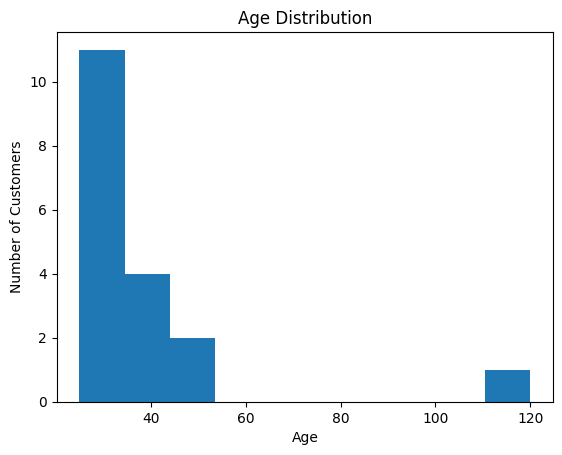

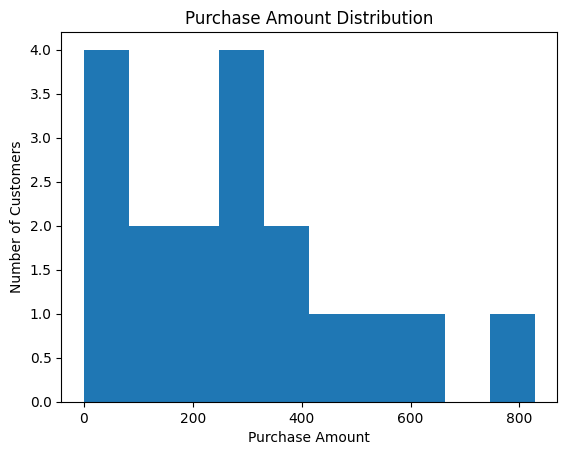

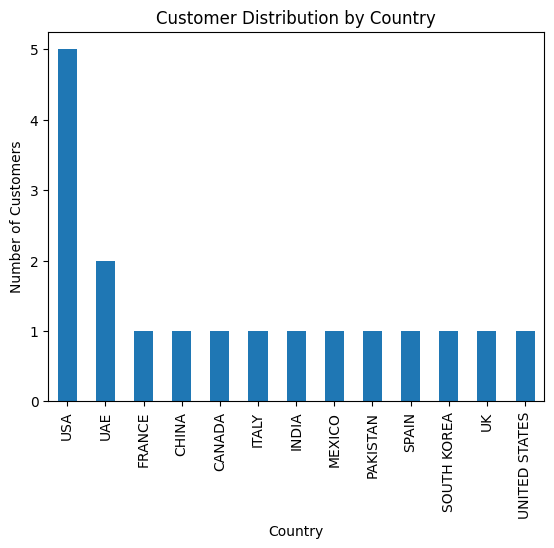

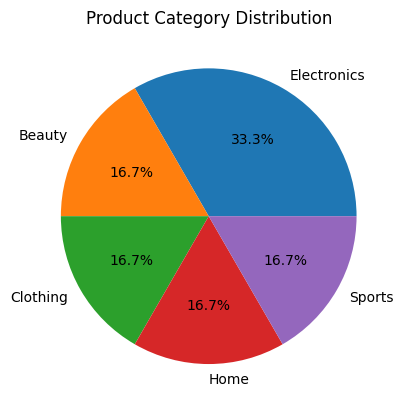

In [95]:
import matplotlib.pyplot as plt
# 1. Age Distribution
plt.figure()
plt.hist(df_clean['age'], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()
# 2. Purchase Amount Distribution
plt.figure()
plt.hist(df_clean['purchase_amount'], bins=10)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Number of Customers")
plt.show()
# 3. Customer Distribution by Country
plt.figure()
df_clean['country'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Customers")
plt.show()
# 4. Product Category Distribution
plt.figure()
df_clean['product_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Product Category Distribution")
plt.ylabel("")  # Hide y-axis label
plt.show()


challenge 3: Advanced Outlier Detection

Implement Z-score method for outlier detection and compare results with IQR method.

**Formula:** Z-score = (value - mean) / standard_deviation

**Threshold:** |Z-score| > 3


In [97]:
import numpy as np
#  Z-score Method for Outlier Detection
# Calculate mean and standard deviation
mean_value = df_clean['purchase_amount'].mean()
std_value = df_clean['purchase_amount'].std()
# Calculate Z-score for each value
df_clean['z_score'] = (
    (df_clean['purchase_amount'] - mean_value) / std_value
)
# Identify Z-score outliers (|Z| > 3)
z_outliers = df_clean[abs(df_clean['z_score']) > 3]
print("Z-score Outliers:")
print("-" * 40)
if z_outliers.empty:
    print("No Z-score outliers found.")
else:
    print(z_outliers[['customer_id', 'purchase_amount', 'z_score']])
# STEP 2: IQR Method for Outlier Detection (Comparison)
Q1 = df_clean['purchase_amount'].quantile(0.25)
Q3 = df_clean['purchase_amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

iqr_outliers = df_clean[
    (df_clean['purchase_amount'] < lower_bound) |
    (df_clean['purchase_amount'] > upper_bound)
]

print("\nIQR Outliers:")
print("-" * 40)

if iqr_outliers.empty:
    print("No IQR outliers found.")
else:
    print(iqr_outliers[['customer_id', 'purchase_amount']])

# STEP 3: Comparison Summary

print("\nOutlier Comparison Summary")
print("-" * 40)
print("Number of Z-score outliers:", len(z_outliers))
print("Number of IQR outliers:", len(iqr_outliers))

# STEP 4: Cleanup (Remove Helper Column)


df_clean.drop(columns=['z_score'], inplace=True)


Z-score Outliers:
----------------------------------------
No Z-score outliers found.

IQR Outliers:
----------------------------------------
No IQR outliers found.

Outlier Comparison Summary
----------------------------------------
Number of Z-score outliers: 0
Number of IQR outliers: 0
